In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from synthetic_generation.gan.models import ImageGenerator, ImageDiscriminator
from synthetic_generation.gan.process import GANProcess

/home/ec2-user/miniconda3/envs/GAN/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load MNIST, normalize to [-1, 1] to match tanh output
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,),(0.5,))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

100%|██████████| 170M/170M [00:02<00:00, 76.5MB/s] 
/home/ec2-user/miniconda3/envs/GAN/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [3]:
class ConditionalDataset(Dataset):
    def __init__(self, mnist_dataset, num_classes=10):
        self.dataset = mnist_dataset
        self.num_classes = num_classes
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        one_hot = torch.zeros(self.num_classes)
        one_hot[label] = 1.0
        return image, one_hot

In [4]:
conditional_dataset = ConditionalDataset(train_dataset)
dataloader = DataLoader(conditional_dataset, batch_size=128, shuffle=True)

In [5]:
G = ImageGenerator(noise_dim = 100, output_dim = (3, 32, 32), conv_in_channels=512, num_conv_layers=3, conditional_dim = 10)
D = ImageDiscriminator(feature_dim = (3, 32, 32), conv_out_channels=64, num_conv_layers=3, conditional_dim=10)
process = GANProcess(G=G, D=D)
history = process.train(
    X=dataloader,
)

GAN training: 100%|██████████| 200/200 [1:41:44<00:00, 30.52s/it, D=0.2104, G=4.8632]


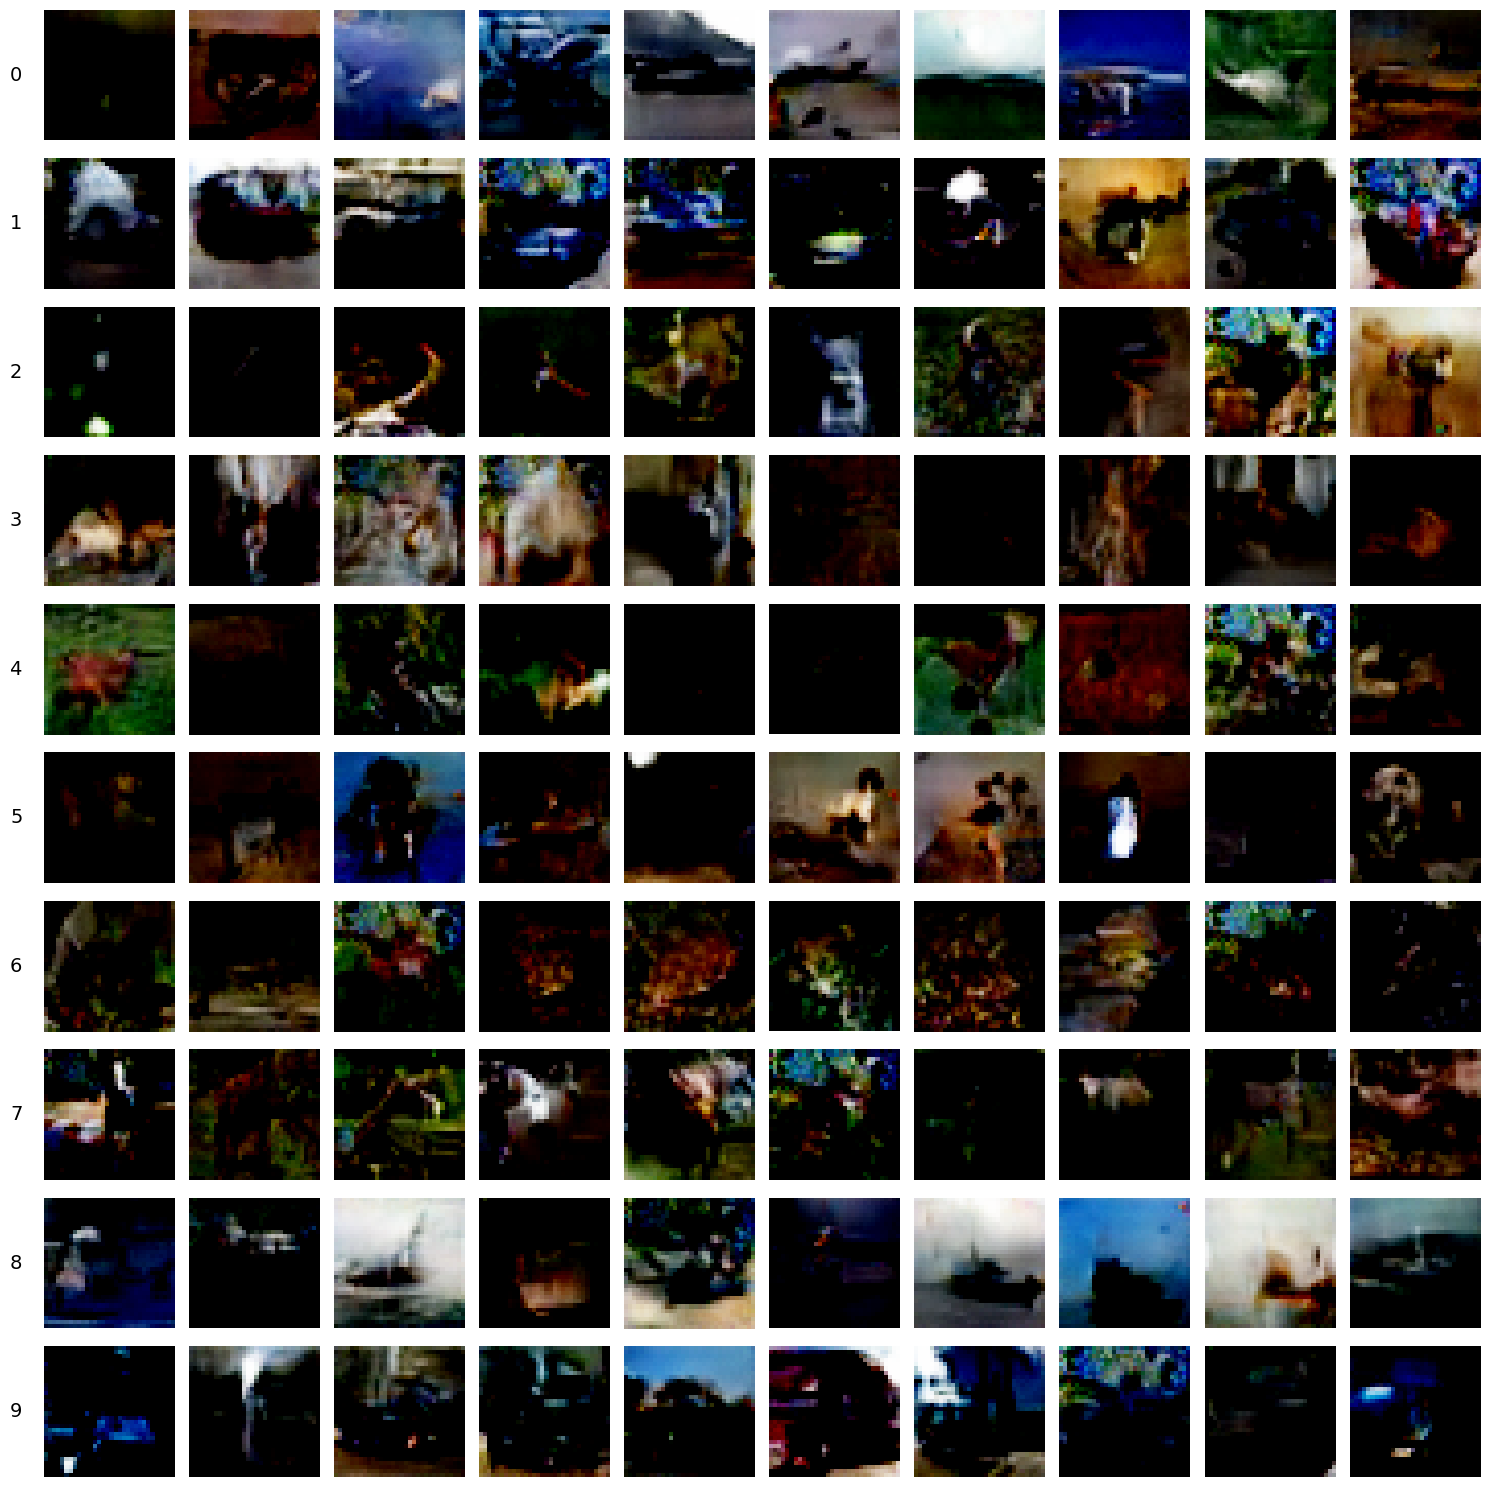

In [6]:
# generate 10 samples per digit class
n_samples = 10
all_samples = []
for digit in range(10):
    c = torch.zeros(n_samples, 10)
    c[:, digit] = 1.0
    samples = process.generate_samples(n_samples, c=c)
    all_samples.append(samples)

# plot 10x10 grid: rows = classes, columns = samples
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
for digit, (row_axes, samples) in enumerate(zip(axes, all_samples)):
    for ax, sample in zip(row_axes, samples):
        ax.imshow(sample.squeeze().permute(1, 2, 0).clip(0, 1))
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    row_axes[0].set_ylabel(str(digit), fontsize=14, rotation=0, labelpad=20, va='center')
plt.tight_layout()
plt.show()